In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 10
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL21lbGFuaWVqZW5zZW4vTGlicmFyeS9DbG91ZFN0b3JhZ2UvT25lRHJpdmUtU291dGhlcm5VdGFoVW5pdmVyc2l0eS9NYXRoLTQ4MTBfQ2Fwc3RvbmUvbWF0ZXJpYWw='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/importlib/_bootstrap.py": 1769647808.3655794, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/importlib/_bootstrap_external.py": 1769647808.3623126, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/zipimport.py": 1769647807.1985786, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/codecs.py": 1769647806.7154012, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/encodings/aliases.py": 1769647807.55931, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/encodings/__init__.py": 1769647807.5555775, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/encodings/utf_8.py": 1769647807.9717433, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/abc.py": 1769647806.6574767, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/io.py": 1769647806.856437, "/Users/melaniejensen/.pyenv/versions/3.12.12/lib/python3.12/stat.py": 1769647807.0671585, "/Users/m

In [2]:
#| label: Initial Imports
#| include: false

import pandas as pd
import numpy as np
from pandas import read_csv
from pandas.core.common import random_state
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import sklearn
import umap
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import PowerTransformer
import hdbscan
from hdbscan import validity
import reverse_geocoder as rg
import cpi
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
#| label: function creation
#| include: false

def normalize(df):
    """
    Returns two dataframes:
    1. df_quantile: Everything forced to normal via Quantile Transformation.
    2. df_comp: Each column transformed by the 'winner' of YJ vs. Quantile.
    """
    df_quantile = pd.DataFrame(index=df.index)
    df_comp = pd.DataFrame(index=df.index)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        data_raw = df[col].values.reshape(-1, 1)

        # Yeo-Johnson
        yj_data, lmbda = stats.yeojohnson(df[col])
        _, yj_p = stats.normaltest(yj_data)
        
        # Normality test for the Quantile data
        qt_engine = QuantileTransformer(output_distribution='normal', 
                                        n_quantiles=min(len(df), 1000), 
                                        random_state=42)
        qt_data = qt_engine.fit_transform(data_raw).flatten()
        _, qt_p = stats.normaltest(qt_data)
        
        if yj_p >= qt_p:
            # Determine suffix for YJ winner
            if -0.1 <= lmbda <= 0.1: suffix = "log"
            elif 0.4 <= lmbda <= 0.6: suffix = "sqrt"
            elif 0.9 <= lmbda <= 1.1: suffix = "linear"
            elif lmbda < 0: suffix = "inv"
            else: suffix = "pow"
            df_comp[f"{col}_{suffix}"] = yj_data
        else:
            df_comp[f"{col}_quant"] = qt_data
            
    print(f"Experiments complete for {len(numeric_cols)} variables.")
    return df_comp

In [4]:
#| label: Read in Parcel Export Sheet 2
#| include: false

parcel_export = pd.read_excel("/Users/melaniejensen/Library/CloudStorage/OneDrive-SouthernUtahUniversity/Math-4810_Capstone/data/Parcel Export.xlsx", sheet_name="Full Parcel Summary")
parcel_export.head()
parcel_export.shape # (53277, 53)
parcel_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53277 entries, 0 to 53276
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ParcelId                     53277 non-null  object 
 1   TaxYear                      53277 non-null  int64  
 2   Active                       53277 non-null  object 
 3   ImpOnly                      53277 non-null  int64  
 4   IsIncluded                   53277 non-null  bool   
 5   PropType                     53277 non-null  int64  
 6   PropTypeDescription          53277 non-null  object 
 7   Subdivision                  38318 non-null  object 
 8   Acreage                      53277 non-null  float64
 9   Jurisdiction                 53277 non-null  int64  
 10  RecordType                   53277 non-null  object 
 11  SpecificPropType             53277 non-null  int64  
 12  SpecificPropTypeDescription  53277 non-null  object 
 13  Lat             

In [5]:
#| label: Non-numeric columns
#| include: false

non_numeric_cols = parcel_export.select_dtypes(exclude=[np.number]).columns.tolist()
parcel_export[non_numeric_cols].shape # (53277, 12)
parcel_export[non_numeric_cols].info()
parcel_export[non_numeric_cols].columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53277 entries, 0 to 53276
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ParcelId                     53277 non-null  object
 1   Active                       53277 non-null  object
 2   IsIncluded                   53277 non-null  bool  
 3   PropTypeDescription          53277 non-null  object
 4   Subdivision                  38318 non-null  object
 5   RecordType                   53277 non-null  object
 6   SpecificPropTypeDescription  53277 non-null  object
 7   ReviewedBy                   52414 non-null  object
 8   NbhdCode2                    53277 non-null  object
 9   Area                         53277 non-null  object
 10  MainImp.GroupCode            21893 non-null  object
 11  Main_StyleDesc               21893 non-null  object
dtypes: bool(1), object(11)
memory usage: 4.5+ MB


Index(['ParcelId', 'Active', 'IsIncluded', 'PropTypeDescription',
       'Subdivision', 'RecordType', 'SpecificPropTypeDescription',
       'ReviewedBy', 'NbhdCode2', 'Area', 'MainImp.GroupCode',
       'Main_StyleDesc'],
      dtype='object')

In [6]:
#| label: Numeric columns
#| include: false

numeric_cols = parcel_export.select_dtypes(include=[np.number]).columns.tolist() 
parcel_export[numeric_cols].shape # (53277, 41)
parcel_export[numeric_cols].info() 
parcel_export[numeric_cols].columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53277 entries, 0 to 53276
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TaxYear                    53277 non-null  int64  
 1   ImpOnly                    53277 non-null  int64  
 2   PropType                   53277 non-null  int64  
 3   Acreage                    53277 non-null  float64
 4   Jurisdiction               53277 non-null  int64  
 5   SpecificPropType           53277 non-null  int64  
 6   Lat                        51923 non-null  float64
 7   Lng                        51923 non-null  float64
 8   ReviewedDate               52414 non-null  float64
 9   ImpCode                    53277 non-null  int64  
 10  Res Imp Count              21893 non-null  float64
 11  TotGLA                     21893 non-null  float64
 12  Tot Bsmt                   21893 non-null  float64
 13  EffYearBuilt_Weighted      21893 non-null  flo

Index(['TaxYear', 'ImpOnly', 'PropType ', 'Acreage', 'Jurisdiction',
       'SpecificPropType', 'Lat', 'Lng', 'ReviewedDate', 'ImpCode',
       'Res Imp Count', 'TotGLA', 'Tot Bsmt', 'EffYearBuilt_Weighted',
       'Quality_Weighted', 'FullBaths_Total', 'HalfBaths_Total',
       'BsmtFinishPct_Weighted', 'Laundry_Count', 'KitchenCount',
       'CarportArea', 'CarportCapacity', 'GarageArea', 'GarageCapacity',
       'Main_YearBuilt', 'Count_DetGarage', 'SqFt_DetGarage',
       'Count_ DetCarport', 'SqFt_DetCarport', 'Count_Barn', 'Sqft_Barn',
       'Count_Guest_House', 'SqFt_Guest_House', 'Count_Pools', 'SqFt_Pools',
       'Count_Recreational_Courts', 'SqFt_Recreational_Courts', 'Count_Shed',
       'SqFt_Shed', 'Count_Gazebo_Pavilion', 'SqFt_Gazebo_Pavilion'],
      dtype='object')

In [7]:
#| label: Numeric Column Adjustment
#| include: false

cols_to_move = ['TaxYear', 'ImpOnly', 'PropType ', 'Jurisdiction', 'SpecificPropType', 'Lat', 'Lng', 'ReviewedDate', 'ImpCode', 'Res Imp Count']
non_numeric_cols = list(set(non_numeric_cols) | set(cols_to_move))
numeric_cols = [c for c in parcel_export.columns if c not in non_numeric_cols]

parcel_export[numeric_cols].shape # (53277, 31)

(53277, 31)

In [8]:
#| label: Fill in NAs for numeric columns with 0
#| include: false

parcel_export[numeric_cols] = parcel_export[numeric_cols].fillna(0)

In [9]:
#| label: Filter Parcel Export for PCA (only numeric columns)
#| include: false

numeric_parcel_data = parcel_export[numeric_cols]

numeric_parcel_data.shape # (53277, 24)
numeric_parcel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53277 entries, 0 to 53276
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Acreage                    53277 non-null  float64
 1   TotGLA                     53277 non-null  float64
 2   Tot Bsmt                   53277 non-null  float64
 3   EffYearBuilt_Weighted      53277 non-null  float64
 4   Quality_Weighted           53277 non-null  float64
 5   FullBaths_Total            53277 non-null  float64
 6   HalfBaths_Total            53277 non-null  float64
 7   BsmtFinishPct_Weighted     53277 non-null  float64
 8   Laundry_Count              53277 non-null  float64
 9   KitchenCount               53277 non-null  float64
 10  CarportArea                53277 non-null  float64
 11  CarportCapacity            53277 non-null  float64
 12  GarageArea                 53277 non-null  float64
 13  GarageCapacity             53277 non-null  flo

In [10]:
#| label: Perform Transformations
#| include: false

df_competition = normalize(numeric_parcel_data)
df_competition.columns

Experiments complete for 31 variables.


Index(['Acreage_inv', 'TotGLA_inv', 'Tot Bsmt_inv',
       'EffYearBuilt_Weighted_inv', 'Quality_Weighted_inv',
       'FullBaths_Total_inv', 'HalfBaths_Total_inv',
       'BsmtFinishPct_Weighted_inv', 'Laundry_Count_inv', 'KitchenCount_inv',
       'CarportArea_inv', 'CarportCapacity_inv', 'GarageArea_inv',
       'GarageCapacity_inv', 'Main_YearBuilt_inv', 'Count_DetGarage_inv',
       'SqFt_DetGarage_inv', 'Count_ DetCarport_inv', 'SqFt_DetCarport_inv',
       'Count_Barn_inv', 'Sqft_Barn_inv', 'Count_Guest_House_inv',
       'SqFt_Guest_House_inv', 'Count_Pools_inv', 'SqFt_Pools_inv',
       'Count_Recreational_Courts_inv', 'SqFt_Recreational_Courts_inv',
       'Count_Shed_inv', 'SqFt_Shed_inv', 'Count_Gazebo_Pavilion_inv',
       'SqFt_Gazebo_Pavilion_inv'],
      dtype='object')

In [11]:
#| label: Scaling the data for PCA
#| include: false

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_competition)

In [12]:
#| label: PCA and Scree Plot
#| include: false

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

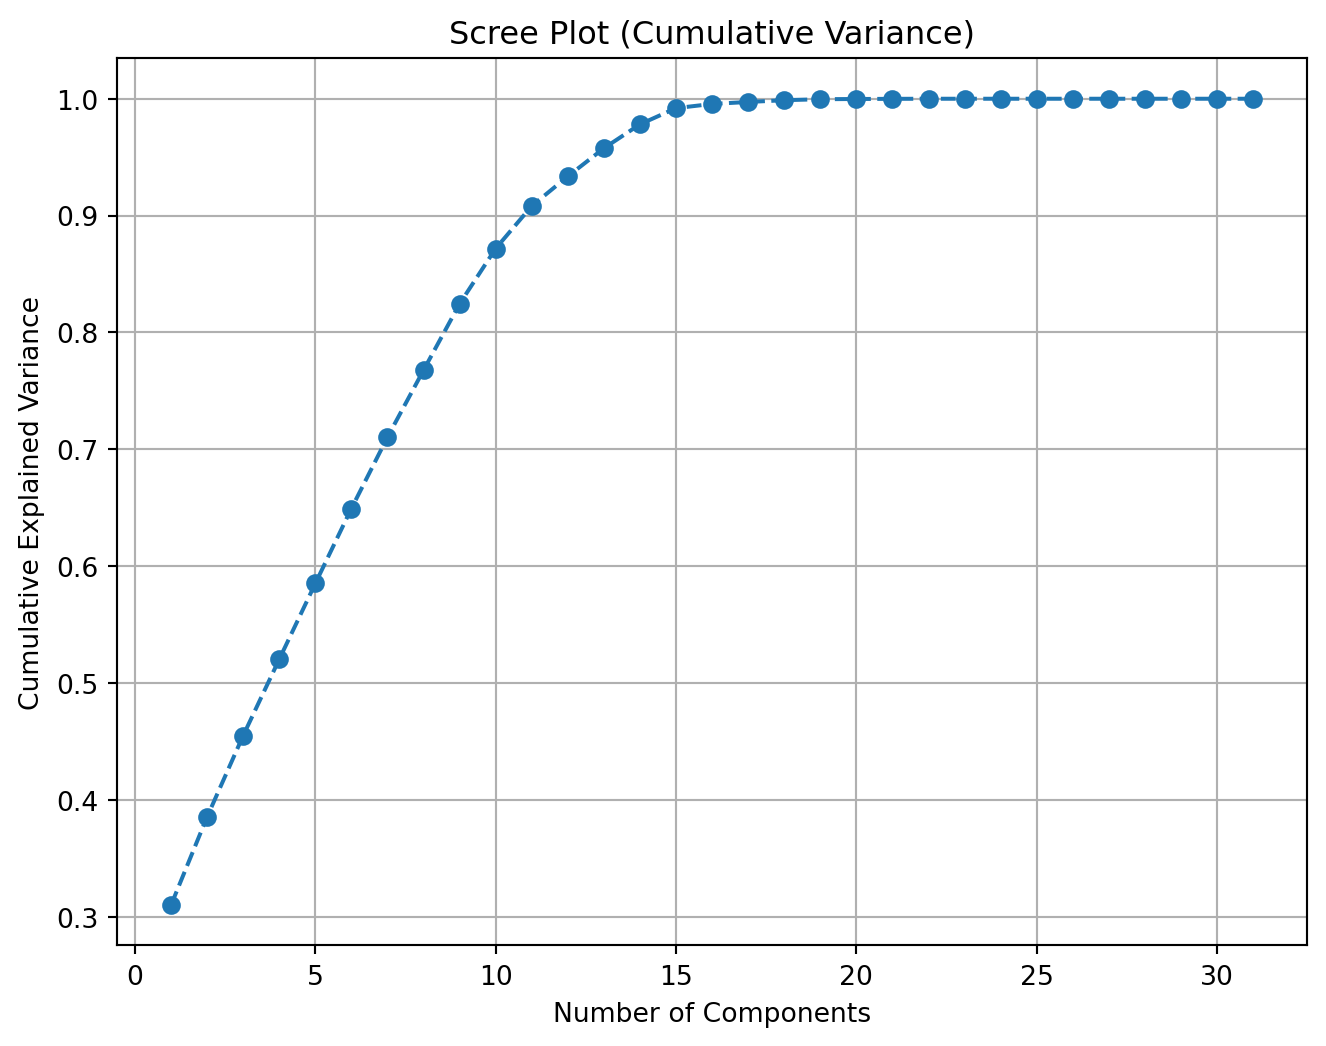

In [13]:
#| label: Scree Plot to optimize number of components
#| warning: false

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o', linestyle='--')
plt.title('Scree Plot (Cumulative Variance)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [14]:
#| label: PCA with 13 components
#| include: false

pca = PCA(n_components=13)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=[
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13'])

pca.explained_variance_ratio_.sum()

np.float64(0.957643490995838)

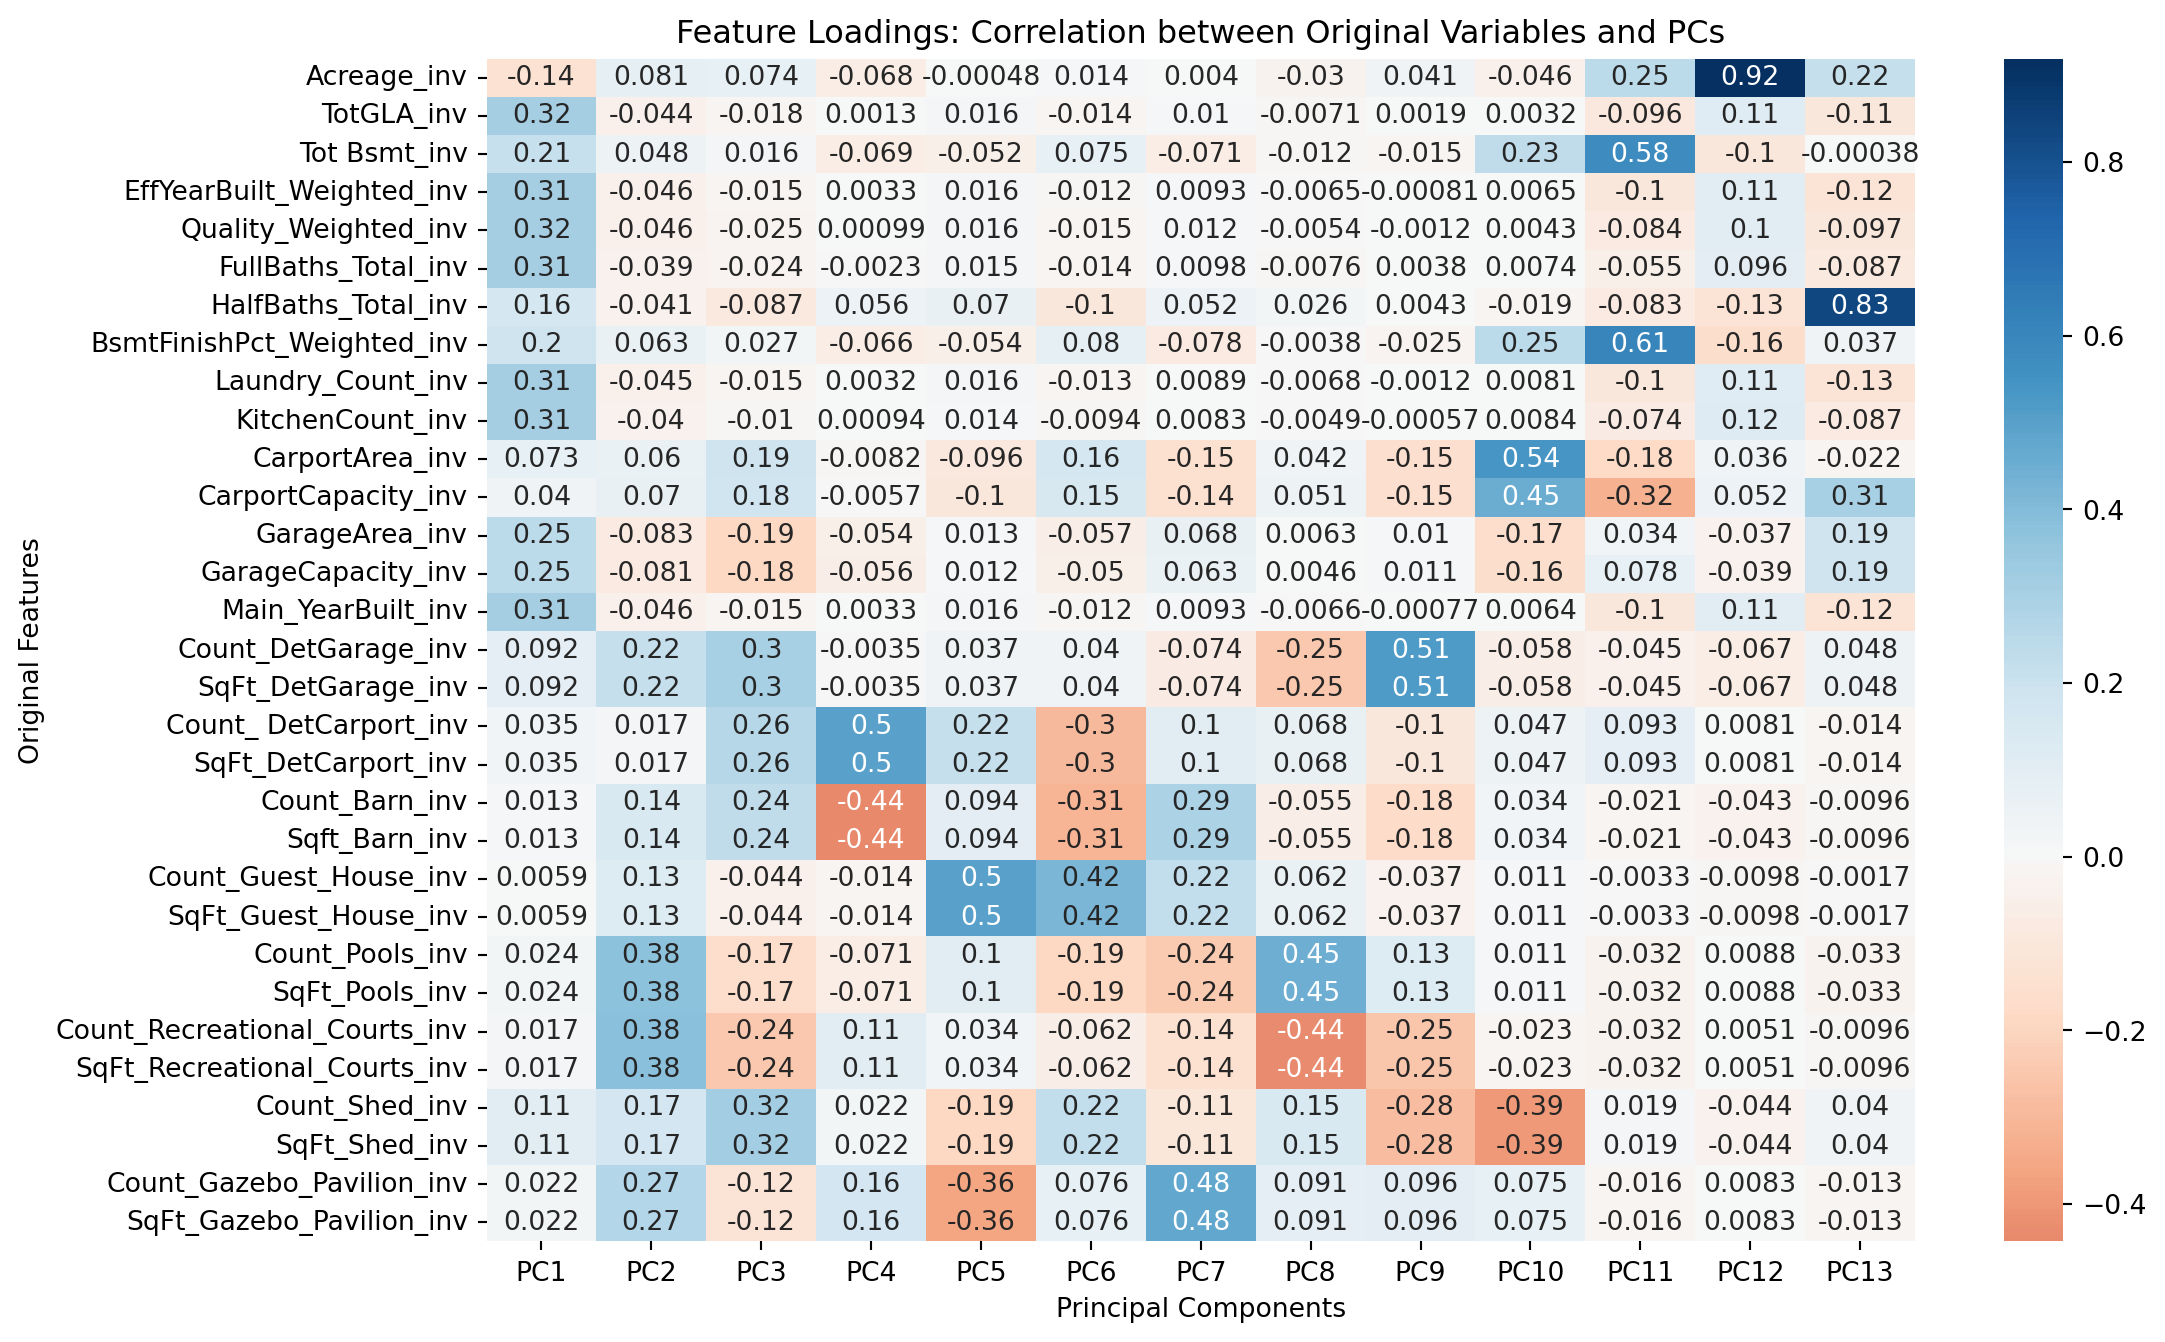

In [15]:
#| label: Loading Matrix
#| warning: false

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=df_competition.columns
)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)

plt.title('Feature Loadings: Correlation between Original Variables and PCs')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.show()